**Structure**

* Summary
* Part 1 - Data Exploration and Preparation
* Part 2: Model Development and Validation
* Part 3: Interpretation and Insights

# Summary<br>
This analysis looks at the Mall Customer Segmentation dataset, consisting 200 customers, three main variables (Age, Annual Income, Spending Score), with Gender thrown in as a secondary factor, to see what natural groupings emerge. The data itself was clean, that means no missing values, no duplicates, a gender split close to even, and just two mildly high Annual Income values that looked like real high-earning customers rather than data errors, so they were kept rather than trimmed. Correlations were weak across the board, Age had a modest negative relationship with Spending Score (0.33), and Annual Income barely moved with either variable, which was actually useful information. It suggested spending isn't driven by any one factor, and a clustering approach made more sense than trying to model it as a simple relationship.

Two feature setups were compared. Approach A used Age, Income, and Spending Score, while Approach B added Gender on top. Both were run through K-Means and Hierarchical clustering, and checked with the Elbow method, Silhouette scores, and a cross-tab comparing to check how much the two algorithms agreed with each other. Approach A came out on top with six clusters that were stable and well-separated with a Silhouette score (0.43), with K-Means and Hierarchical landing on largely the same groupings. Approach B was messier with a lower Silhouette score (0.33) and noticeably more disagreement between the two methods. In other words, adding Gender didn't help, if anything it blurred the clusters. So Approach A with K-Means at k=6 was picked as the final model, and a PCA projection backed this up, with the six groups still visually distinct even when compressed into two dimensions (77.6% of the variance retained).

What the six segments show is that income and spending don't line up the way you'd expect. A few cluster pairs sit at similar income levels but split sharply on spending, and in most of those cases Age is what's actually pulling them apart, not income at all.
That points to some practical takeaways; focus retention efforts on the high spenders, since they're the most valuable group; run more targeted campaigns for the high-income-but-low-spending customers, who clearly aren't being reached effectively; and consider loyalty programs aimed at younger customers who spend enthusiastically despite tighter budgets.

The obvious caveats are worth stating plainly too — this is a small dataset, there's no behavioral or time-based data to work with, and it's not clear how Spending Score was even calculated in the first place. All of that is really a roadmap for what a follow-up analysis should try to fix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
mallcus = pd.read_csv('https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv')
mallcus.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Part 1: Data Exploration and Preparation

### 1.1 – Structure check

**Shape**

In [3]:
print("Shape:", mallcus.shape)
mallcus.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**Missing & Duplicate Values**

In [4]:
print("Missing values:\n", mallcus.isnull().sum())
print("\nDuplicate rows:", mallcus.duplicated().sum())
print("Duplicate CustomerID", mallcus['CustomerID'].duplicated().sum())

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0
Duplicate CustomerID 0


**Finding:** Dataset has 200 rows, 5 columns, no missing values and no duplicates, means no cleaning required at this stage.

### 1.2 Descriptive Statistics

In [5]:
mallcus.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


**Finding:**
* Customers range in age from 18–70 (mean ~39)
* Annual income from 15k–137k (mean ~60.5k)
* Spending score from 1–99 (mean ~50.2).
* Gender is 112 Female / 88 Male, not heavily imbalanced.
* CustomerID is just a row identifier and won't be used as a feature.

### 1.3 Univariate Distributions

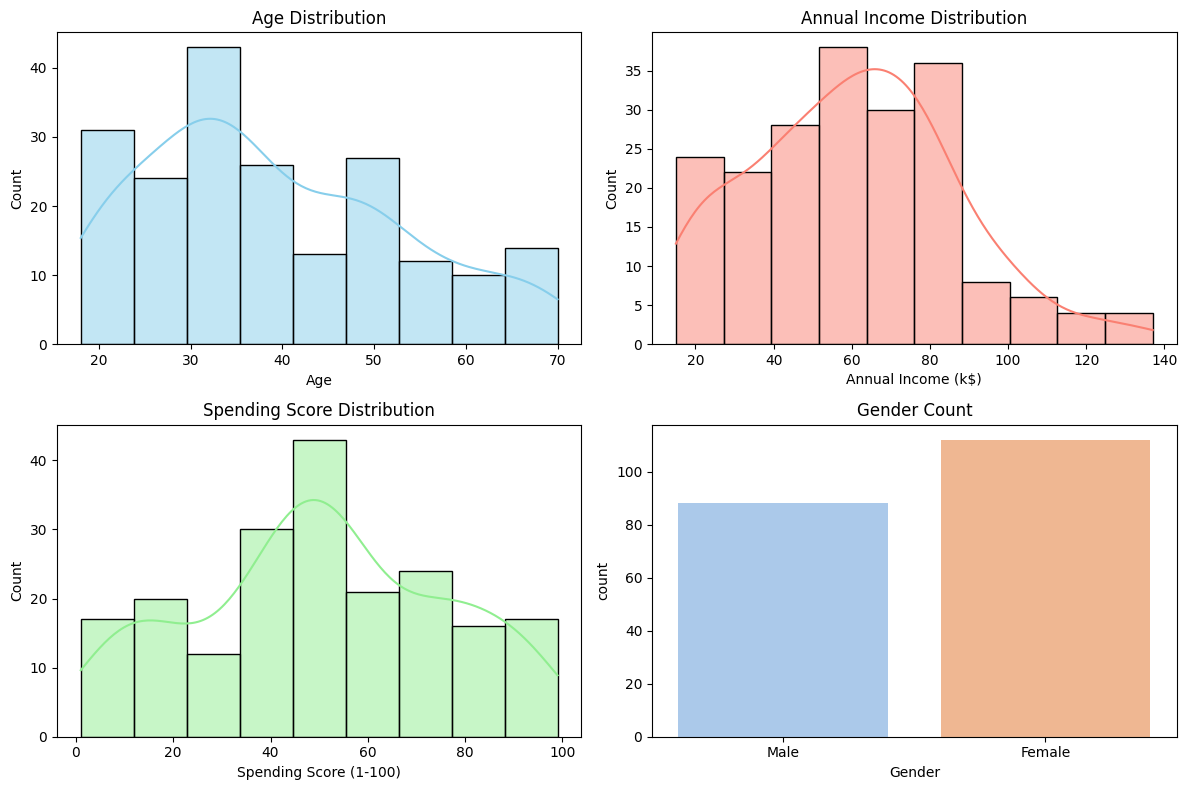

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(mallcus['Age'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(mallcus['Annual Income (k$)'], kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Annual Income Distribution')

sns.histplot(mallcus['Spending Score (1-100)'], kde=True, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Spending Score Distribution')

sns.countplot(x='Gender', data=mallcus, ax=axes[1,1], palette='pastel')
axes[1,1].set_title('Gender Count')

plt.tight_layout()
plt.show()

**Finding:**
* Age is right-skewed with most customers in their 20s-30s.
* Annual Income is roughly unimodal with a long right tail (a few high-income outliers).
* Spending Score shows a bimodal pattern with a concentration around 40-60 and secondary bumps at the extremes, this hints that natural customer segments may already exist, which is relevant for the clustering task ahead.
* Gender distribution is fairly balanced.

### 1.4 Correlation Analysis

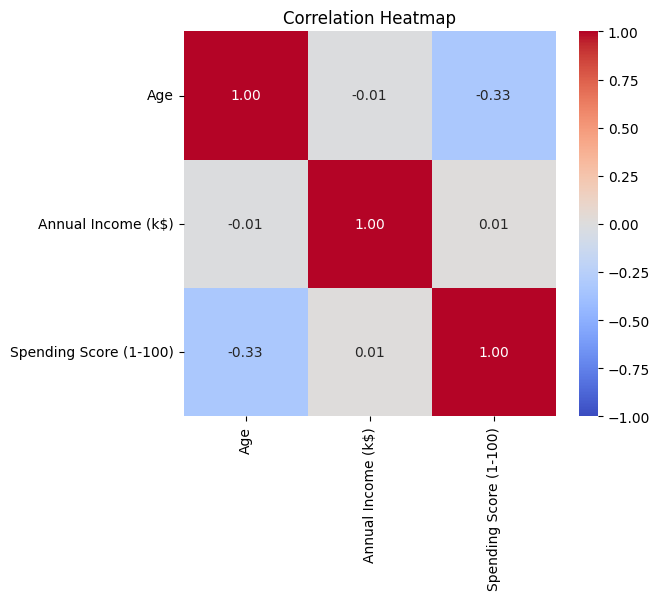

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [7]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = mallcus[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

corr

**Finding:**
* Age has a moderate negative correlation with Spending Score (-0.33), older customers tend to spend somewhat less.
* Annual Income shows almost no linear correlation with either Age (-0.01) or Spending Score (0.01), meaning income alone doesn't predict spending behavior.<br>

Customers likely need to be grouped using combinations of these variables rather than any single one. This supports the need for clustering (Part 2) rather than a simple linear relationship.

### 1.5 Outlier Detection

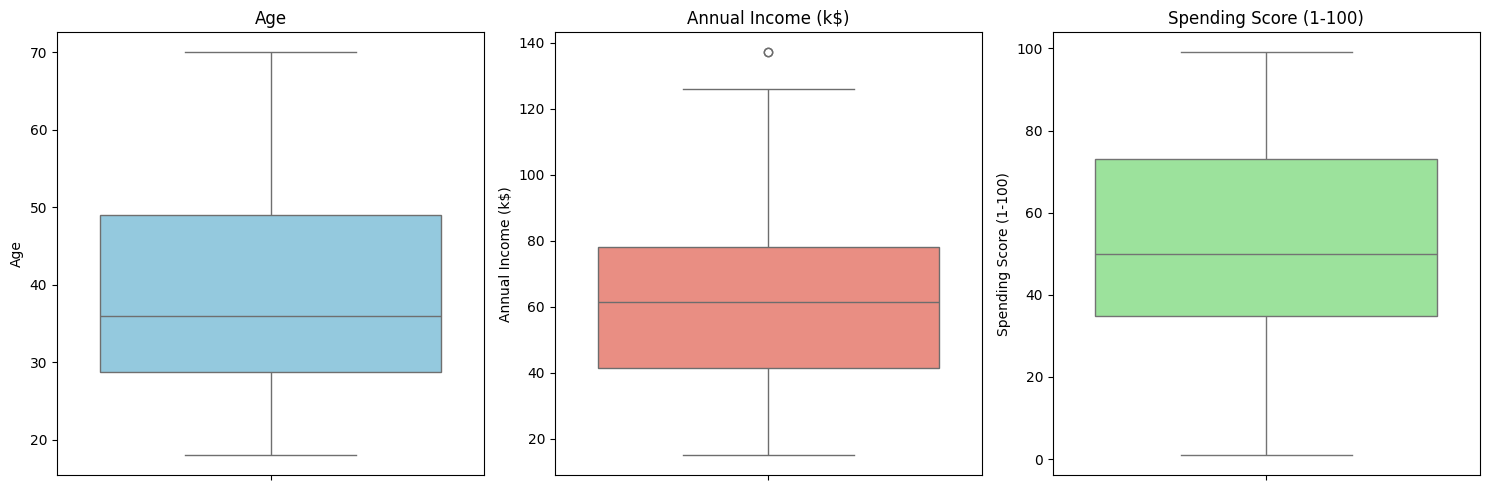

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=mallcus['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age')

sns.boxplot(y=mallcus['Annual Income (k$)'], ax=axes[1], color='salmon')
axes[1].set_title('Annual Income (k$)')

sns.boxplot(y=mallcus['Spending Score (1-100)'], ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score (1-100)')

plt.tight_layout()
plt.show()

**IQR-based**

In [9]:
for col in numeric_cols:
    Q1 = mallcus[col].quantile(0.25)
    Q3 = mallcus[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = mallcus[(mallcus[col] < lower) | (mallcus[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.1f} to {upper:.1f})")

Age: 0 outliers (bounds: -1.6 to 79.4)
Annual Income (k$): 2 outliers (bounds: -13.2 to 132.8)
Spending Score (1-100): 0 outliers (bounds: -22.6 to 130.4)


In [10]:
print("Annual Income (k$) 100th percentile: ",mallcus['Annual Income (k$)'].quantile(1))
print("Number of customers income $137: ", mallcus[mallcus['Annual Income (k$)'] == 137].shape[0])

Annual Income (k$) 100th percentile:  137.0
Number of customers income $137:  2


**Finding:** IQR method flags 0 outliers in Age and Spending Score, and only 2 in Annual Income.

**Decision:** These 2 income outliers are retained. With only 200 records, removing data would shrink an already small dataset. And these aren't data-entry errors, they represent genuinely high-income customers who are a legitimate (and business-relevant) segment for a mall to understand. Since we're heading into clustering, we'll standardize features before modeling, which reduces the influence of scale differences. If these points later prove to distort cluster shapes, we'll revisit this decision in Part 2.

### 1.6 Categorical Encoding

In [11]:
mallcus['Gender_Encoded'] = mallcus['Gender'].map({'Male': 0, 'Female': 1})
mallcus[['Gender', 'Gender_Encoded']].head()

,Gender,Gender_Encoded
0,Male,0
1,Male,0
2,Female,1
3,Female,1
4,Female,1


**Justification:** Gender is a binary categorical variable, so it's encoded as a single 0/1 column (Male=0, Female=1) rather than one-hot encoding, which would be redundant for a two-category variable. CustomerID is excluded from analysis since it's just a row identifier with no analytical value.

# Part 2: Model Development and Validation

**In Part 2 we are going to Develope, Validate and Compare 2 approaches:**


*   **Approach A:** Age + Annual Income + Spending Score (3 features, uses everything numeric)
*   **Approach B:** Approach A + Gender_Encoded (adds the categorical dimension)



### 2.1 Feature Scaling

Since K-Means and Hierarchical clustering are distance-based, all features need to be on the same scale

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# Approach A
features_A = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_A = mallcus[features_A]
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

In [14]:
# Approach B
features_B = features_A + ['Gender_Encoded']
X_B = mallcus[features_B]
scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)

In [15]:
print("X_A_scaled shape:", X_A_scaled.shape, X_A_scaled[0])
print("\nX_B_scaled shape:", X_B_scaled.shape, X_B_scaled[0])


X_A_scaled shape: (200, 3) [-1.42456879 -1.73899919 -0.43480148]

X_B_scaled shape: (200, 4) [-1.42456879 -1.73899919 -0.43480148 -1.12815215]


**Justification:** StandardScaler is used to standardize all features to mean=0, std=1, since K-Means and Hierarchical clustering rely on Euclidean distance and are sensitive to feature scale.<br>
Without scaling, Annual Income (range 15-137) would dominate the distance calculations over Spending Score (range 1-99) and Age (range 18-70), and Gender_Encoded (0/1) would barely register at all.

### 2.2 Optimal k - Approach A (Age + Annual Income + Spending Score)

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
wcss_A = []
sil_scores_A = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_A_scaled)
    wcss_A.append(km.inertia_)
    sil_scores_A.append(silhouette_score(X_A_scaled, labels))

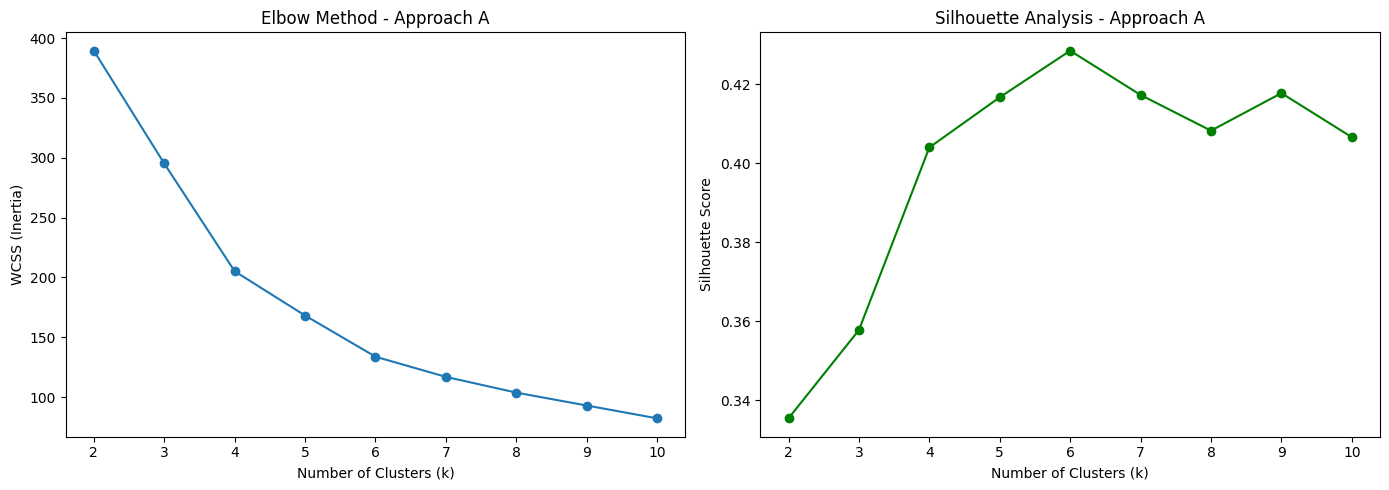

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss_A, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method - Approach A')

axes[1].plot(list(k_range), sil_scores_A, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis - Approach A')

plt.tight_layout()
plt.show()

In [19]:
for k, s in zip(k_range, sil_scores_A):
    print(f"k={k}: silhouette={s:.4f}")

k=2: silhouette=0.3355
k=3: silhouette=0.3578
k=4: silhouette=0.4040
k=5: silhouette=0.4166
k=6: silhouette=0.4284
k=7: silhouette=0.4172
k=8: silhouette=0.4082
k=9: silhouette=0.4177
k=10: silhouette=0.4066


**Finding:**
* **Elbow Method**: The Elbow plot shows WCSS dropping sharply until around k=4-6,
after which the decrease flattens out — the "elbow" is not razor-sharp but sits around k=5-6.
* **Silhouette Method**: The Silhouette scores peak at k=6 (0.4284), with k=5 (0.4166) and k=7 (0.4172) close behind.

**Decision:** We select `k=6` for Approach A, since it has the highest silhouette score and aligns with the elbow region, indicating well-separated, reasonably compact clusters at this value.

### 2.3 K-Means Clustering - Approach A

In [20]:
kmeans_A = KMeans(n_clusters=6, random_state=42, n_init=10)
mallcus['Cluster_KMeans_A'] = kmeans_A.fit_predict(X_A_scaled)

In [21]:
print(mallcus['Cluster_KMeans_A'].value_counts().sort_index())

Cluster_KMeans_A
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


**2D Visualization**

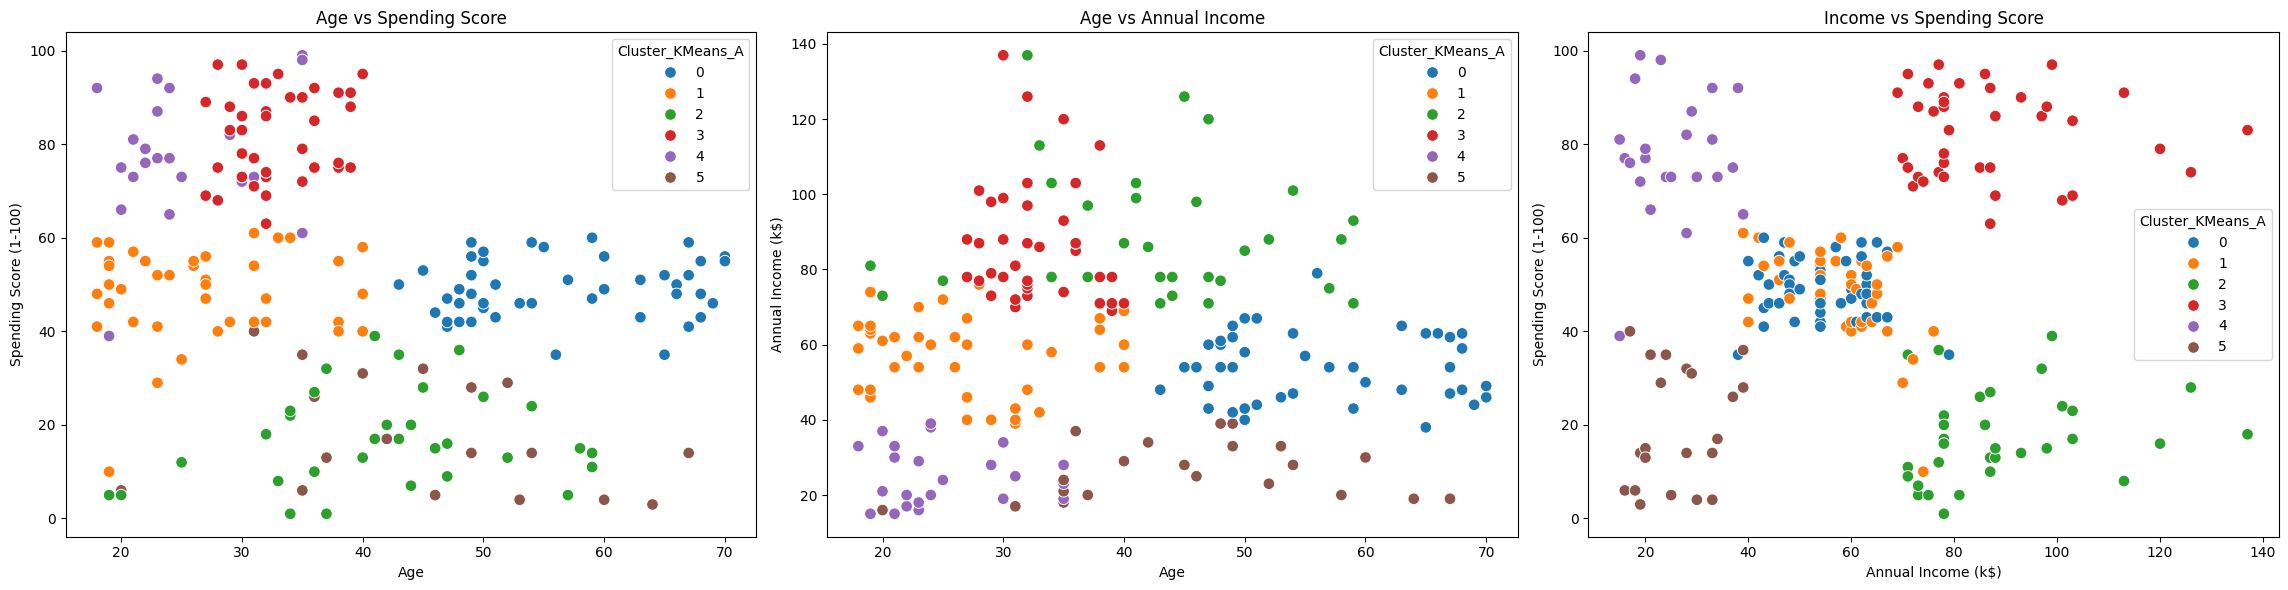

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(23, 6))

sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster_KMeans_A', data=mallcus, palette='tab10', s=70
)
axes[0].set_title('Age vs Spending Score')

sns.scatterplot(
    x='Age', y='Spending Score (1-100)',
    hue='Cluster_KMeans_A', data=mallcus, palette='tab10', s=70, ax=axes[0]
)
axes[1].set_title('Age vs Annual Income')

sns.scatterplot(
    x='Age', y='Annual Income (k$)',
    hue='Cluster_KMeans_A', data=mallcus, palette='tab10', s=70, ax=axes[1]
)
axes[2].set_title('Income vs Spending Score')

plt.tight_layout()
plt.show()

**3D Visualization**

In [23]:
import plotly.express as px

In [24]:
fig = px.scatter_3d(
    mallcus,
    x='Age', y='Annual Income (k$)', z='Spending Score (1-100)',
    color=mallcus['Cluster_KMeans_A'].astype(str),
    title='K-Means Clusters (Approach A, k=6) — Interactive 3D View',
    labels={'color': 'Cluster'},
    opacity=0.8
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(width=800, height=700)
fig.show()

**Finding (Updated):** Viewing the clusters across all feature combinations confirms that the 6 K-Means clusters are meaningfully separated once all 3 dimensions are considered together:
* **Income vs Spending Score:** 4 of the 6 clusters (red, purple, brown, green) are visually well-separated. They correspond to the corner segments (low income/low spending, low income/high spending, high income/low spending, high income/high spending). However, two clusters (blue=0 and orange=1) overlap heavily in the middle-income, middle-spending region.
* **Age vs Spending Score:** Clusters 0 (blue) and 1 (orange), which overlapped in the Income vs Spending Score view, separate clearly here. Cluster 0 (older, 40-70) and Cluster 1 (younger, 20-40) both sit in the mid-range of spending score.
* **Age vs Annual Income:** Clusters 3 (red) and 2 (green) stand out as higher-income groups across a range of ages, while 1 (orange) and 5 (brown) represent lower-income, younger-to-mixed-age groups.
* **Interactive 3D view:** All 6 clusters form visually distinct, well-separated groupings when Age, Income, and Spending Score are viewed together, confirming that Approach A's clustering makes sense in the full 3D space, even though no single 2D projection shows all 6 clusters separated simultaneously.


**Conclusion:** k=6 with 3 features produces genuinely distinct segments, but interpretation requires looking at combinations of features rather than any single pair. This naturaly points at using PCA to get one comprehensive 2D view later.

### 2.4 Hierarchical Clustering - Approach A

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

In [26]:
linked_A = linkage(X_A_scaled, method='ward')

In [27]:
for h in [5, 6, 7, 8, 9, 10]:
    n_clusters = len(set(fcluster(linked_A, h, criterion='distance')))
    print(f"height={h}: {n_clusters} clusters")

height=5: 8 clusters
height=6: 6 clusters
height=7: 6 clusters
height=8: 6 clusters
height=9: 6 clusters
height=10: 4 clusters


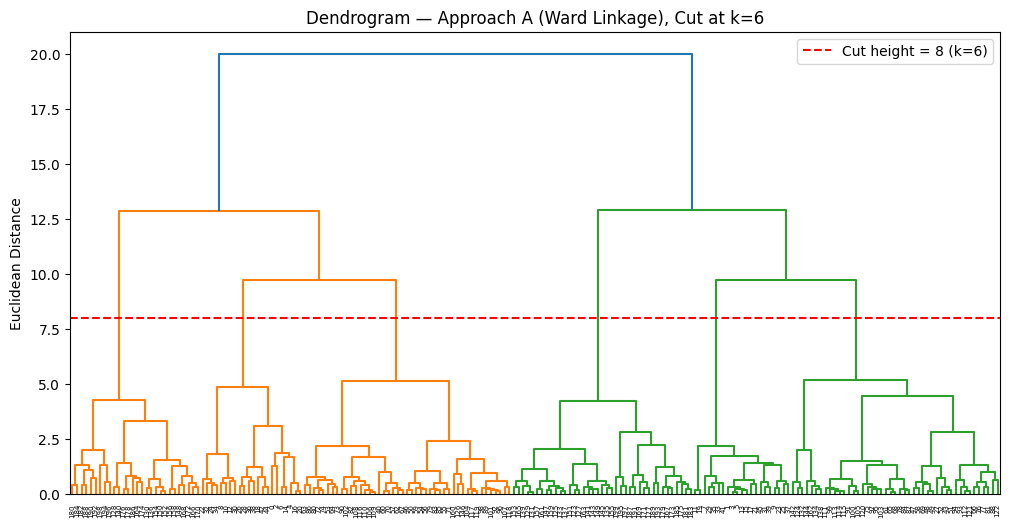

In [28]:
plt.figure(figsize=(12, 6))
dendrogram(linked_A)
plt.axhline(y=8, color='r', linestyle='--', label='Cut height = 8 (k=6)')
plt.title('Dendrogram — Approach A (Ward Linkage), Cut at k=6')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.show()

**6 hierarchical clusters**

In [29]:
mallcus['Cluster_Hier_A'] = fcluster(linked_A, 8, criterion='distance')

print(mallcus['Cluster_Hier_A'].value_counts().sort_index())

Cluster_Hier_A
1    28
2    22
3    45
4    39
5    21
6    45
Name: count, dtype: int64


**Finding:** The dendrogram shows two major branches (orange and green) splitting at a high distance (3), each of which further subdivides. Testing cut heights shows a wide stable range (heights 6-9) all yielding 6 clusters — this stability suggests k=6 is a natural, well-supported grouping in this data, not an artifact of picking one exact cut point. This aligns with the k=6 chosen for K-Means via the Elbow/Silhouette analysis.

**Decision:** We cut the dendrogram at height=8 (the middle of the stable range) using Ward linkage, producing cluster sizes of 28, 22, 45, 39, 21, and 45, reasonably balanced, similar in spirit to the K-Means cluster sizes (21-45).

### 2.5 Evaluation - K-Means vs Hierarchical (Approach A)

**Silhouette scores for both methods**

In [30]:
sil_kmeans_A = silhouette_score(X_A_scaled, mallcus['Cluster_KMeans_A'])
sil_hier_A = silhouette_score(X_A_scaled, mallcus['Cluster_Hier_A'])

In [31]:
print(f"K-Means Silhouette Score (Approach A): {sil_kmeans_A:.4f}")
print(f"Hierarchical Silhouette Score (Approach A): {sil_hier_A:.4f}")

K-Means Silhouette Score (Approach A): 0.4284
Hierarchical Silhouette Score (Approach A): 0.4201


**Cross-tab**

In [32]:
print("Cross-tab: K-Means vs Hierarchical clusters (Approach A)")
print(pd.crosstab(mallcus['Cluster_KMeans_A'], mallcus['Cluster_Hier_A']))

Cross-tab: K-Means vs Hierarchical clusters (Approach A)
Cluster_Hier_A     1   2   3   4   5   6
Cluster_KMeans_A                        
0                  0   0  43   0   0   2
1                  0   0   0   0   0  39
2                 28   0   2   0   0   3
3                  0   0   0  39   0   0
4                  0   1   0   0  21   1
5                  0  21   0   0   0   0


**Finding:**
* **Cross-tab:** The crosstab shows strong agreement between K-Means and Hierarchical clustering. Most K-Means clusters map almost entirely onto a single Hierarchical cluster (e.g., K-Means cluster 1 - 39/39 in Hier 6; K-Means cluster 3 - 39/39 in Hier 4; K-Means cluster 5 - 21/21 in Hier 2; K-Means cluster 0 - 43/45 in Hier 3). Only minor cross-over exists, confirming both algorithms are detecting the same underlying customer segments, not arbitrary or unstable groupings.
* **Shilhoutte:** Silhouette scores are close, K-Means = 0.4284 vs Hierarchical = 0.4201. K-Means performs marginally better.



**Conclusion:** For Approach A, we select `K-Means (k=6)` as the primary model for this feature set going forward, since it has the (marginally) higher silhouette score and is computationally simpler to interpret.

### 2.6 Optimal k - Approach B (Age, Income, Spending Score, Gender)

In [33]:
wcss_B = []
sil_scores_B = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_B_scaled)
    wcss_B.append(km.inertia_)
    sil_scores_B.append(silhouette_score(X_B_scaled, labels))

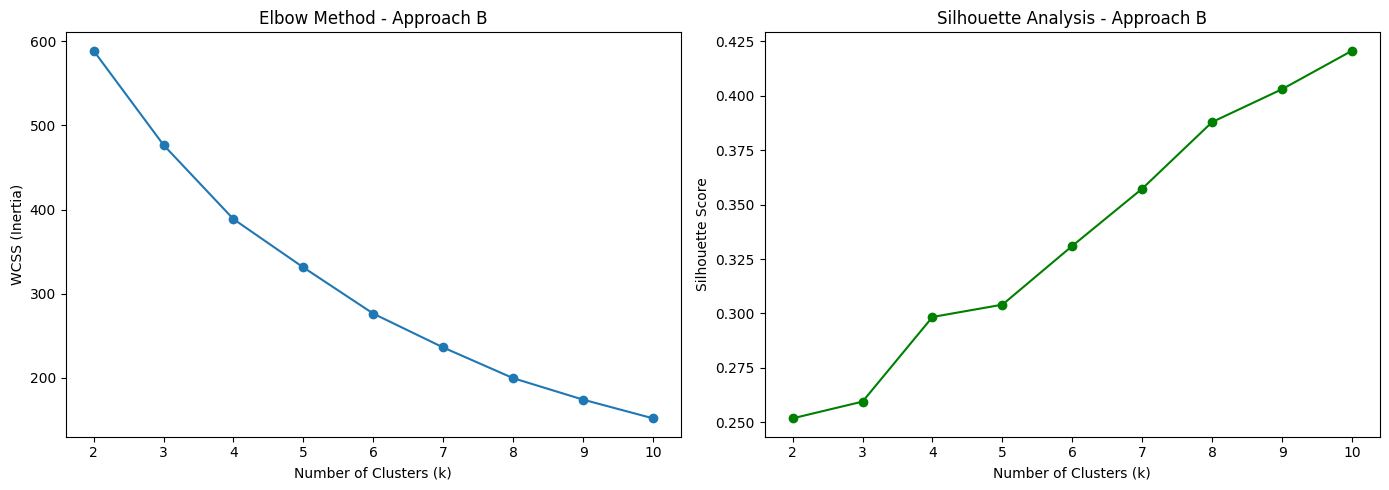

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss_B, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method - Approach B')

axes[1].plot(list(k_range), sil_scores_B, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis - Approach B')

plt.tight_layout()
plt.show()

In [35]:
for k, s in zip(k_range, sil_scores_B):
    print(f"k={k}: silhouette={s:.4f}")

k=2: silhouette=0.2518
k=3: silhouette=0.2595
k=4: silhouette=0.2984
k=5: silhouette=0.3041
k=6: silhouette=0.3311
k=7: silhouette=0.3574
k=8: silhouette=0.3880
k=9: silhouette=0.4031
k=10: silhouette=0.4208


**Finding:**
* **Silhouette Method:** Unlike Approach A, the Silhouette scores for Approach B increase monotonically from k=2 to k=10, never peaking within the tested range, the score keeps climbing right up to the max k=10 (0.4208). This is a red flag, because a silhouette curve that never turns over usually means the algorithm isn't finding natural, well-separated groups.
* **Elbow Method:** The Elbow plot shows a smooth, gradual decline with no sharp bend, less clear-cut than Approach A's plot.

**Trying with 'k' uptill 15**

In [36]:
wcss_Bk15 = []
sil_scores_Bk15 = []

for k in range(2,15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_B_scaled)
    wcss_Bk15.append(km.inertia_)
    sil_scores_Bk15.append(silhouette_score(X_B_scaled, labels))

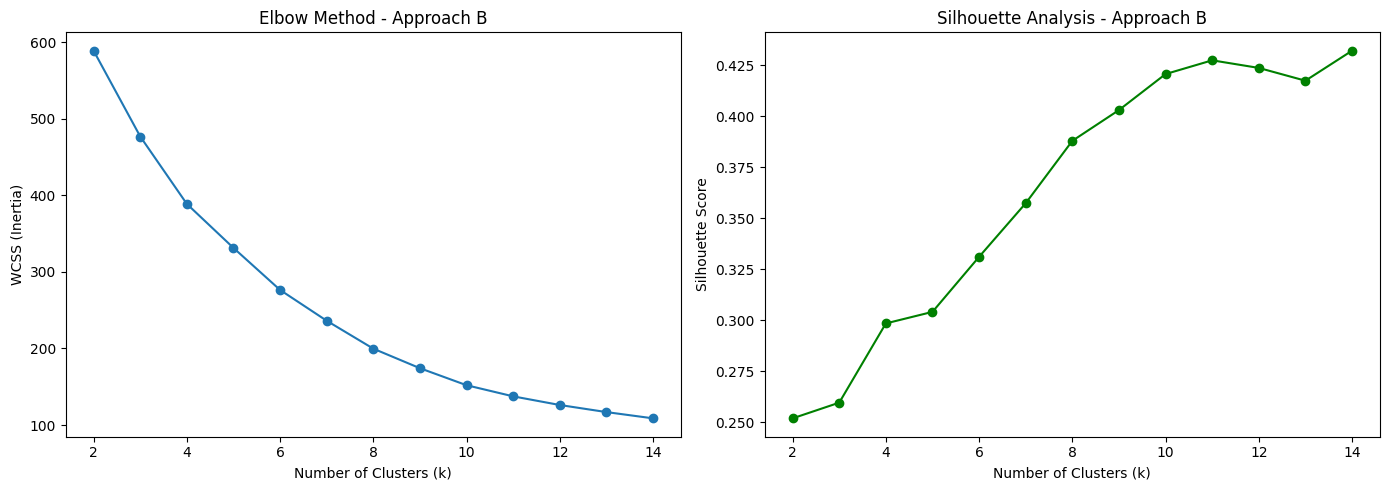

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(range(2,15)), wcss_Bk15, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method - Approach B')

axes[1].plot(list(range(2,15)), sil_scores_Bk15, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis - Approach B')

plt.tight_layout()
plt.show()

**Finding:** Extending the range to k=15 shows the Silhouette curve is not purely monotonic after all, it rises steadily, peaks around k=11 (0.43), dips slightly at k=12-13, then rises again toward k=14-15. This pattern suggests the addition of Gender_Encoded doesn't create the same well-defined natural groupings that Approach A had. Instead, the algorithm keeps carving out smaller, more specific subgroups.

**Decision:** We still select k=6 for Approach B, for two reasons:
1) It keeps the comparison with Approach A fair and controlled. Same k, only Gender added.
2) A "best" k of 11-15 would produce clusters too small and fragmented (likely under 15-20 customers) to be useful for a mall's segmentation purposes, even if it scores marginally higher on silhouette.<br>

This is a case where statistical optimality and business interpretability diverge, and we prioritize interpretability.

### 2.7 - Apply K-Means + Hierarchical for Approach B (k=6)

**K-Means**

In [38]:
kmeans_B = KMeans(n_clusters=6, random_state=42, n_init=10)
mallcus['Cluster_KMeans_B'] = kmeans_B.fit_predict(X_B_scaled)

**Hierarchical**

In [39]:
linked_B = linkage(X_B_scaled, method='ward')
mallcus['Cluster_Hier_B'] = fcluster(linked_B, t=6, criterion='maxclust')


**Clusters**

In [40]:
print("K-Means B cluster sizes:\n", mallcus['Cluster_KMeans_B'].value_counts().sort_index())
print("\nHierarchical B cluster sizes:\n", mallcus['Cluster_Hier_B'].value_counts().sort_index())

K-Means B cluster sizes:
 Cluster_KMeans_B
0    41
1    38
2    34
3    35
4    23
5    29
Name: count, dtype: int64

Hierarchical B cluster sizes:
 Cluster_Hier_B
1    39
2    23
3    38
4    33
5    29
6    38
Name: count, dtype: int64


**Finding:** Both algorithms produce reasonably balanced cluster sizes at k=6. K-Means sizes range from 23 to 41; Hierarchical sizes range from 23 to 39.Similar spread to what we saw in Approach A, with no cluster being too small or dominating.

### 2.8 Evaluation - K-Means vs Hierarchical (Approach B)

**Silhouette scores for both methods**

In [41]:
sil_kmeans_B = silhouette_score(X_B_scaled, mallcus['Cluster_KMeans_B'])
sil_hier_B = silhouette_score(X_B_scaled, mallcus['Cluster_Hier_B'])

In [42]:
print(f"K-Means Silhouette Score (Approach B): {sil_kmeans_B:.4f}")
print(f"Hierarchical Silhouette Score (Approach B): {sil_hier_B:.4f}")

K-Means Silhouette Score (Approach B): 0.3311
Hierarchical Silhouette Score (Approach B): 0.3102


**Cross-tab**

In [43]:
print("Cross-tab: K-Means vs Hierarchical clusters (Approach B)")
print(pd.crosstab(mallcus['Cluster_KMeans_B'], mallcus['Cluster_Hier_B']))

Cross-tab: K-Means vs Hierarchical clusters (Approach B)
Cluster_Hier_B     1   2   3   4   5   6
Cluster_KMeans_B                        
0                  0   0   4   2   0  35
1                 16  21   0   0   1   0
2                  0   0  31   0   0   3
3                  0   2   0   5  28   0
4                 23   0   0   0   0   0
5                  0   0   3  26   0   0


**Finding:**
* **Silhouette:** K-Means silhouette (0.3311) again edges out Hierarchical (0.3102) for Approach B, consistent with the pattern seen in Approach A.
* **Cross-tab:** The crosstab shows weaker agreement between the two methods compared to Approach A. Several K-Means clusters split across two Hierarchical clusters rather than mapping cleanly onto one (e.g., K-Means cluster 1 splits 16/21/1 across Hier 1/2/5; K-Means cluster 3 splits 5/28 across Hier 4/5). Only clusters 0, 2, and 4 show strong one-to-one correspondence.

This weaker agreement suggests the cluster boundaries in Approach B are less stable/well-defined than in Approach A, similar to what we saw while finding optimal 'k' (2.6).

**Conclusion:** Both silhouette scores (0.3311/0.3102) and crosstab agreement are lower for Approach B than Approach A (0.4284/0.4201). K-Means remains the stronger algorithm of the two within Approach B as well.

### 2.9 Approach A vs Approach B - Final Comparison

In [44]:
comparison = pd.DataFrame({
    'Approach': ['A (Age, Income, Spending)', 'B (A + Gender)'],
    'KMeans Silhouette': [sil_kmeans_A, sil_kmeans_B],
    'Hierarchical Silhouette': [sil_hier_A, sil_hier_B],
    'K-Means/Hier Agreement': ['Strong', 'Weaker']
})
comparison

,Approach,KMeans Silhouette,Hierarchical Silhouette,K-Means/Hier Agreement
0,"A (Age, Income, Spending)",0.428417,0.420117,Strong
1,B (A + Gender),0.331074,0.310245,Weaker


**Final Decision:** Approach A (Age, Annual Income, Spending Score) is selected as the best model, using **K-Means with k=6**. It achieves a notably higher silhouette score (0.4284 vs 0.3311) and shows strong agreement with Hierarchical clustering, both signs of more genuine, well-separated customer segments.<br>
Approach B is not discarded as wasted effort, however, it demonstrates that Gender does not meaningfully improve segmentation for this dataset. Spending behavior patterns are driven by Age and Income, not Gender, which is itself a useful business insight. Marketing strategies built on these clusters shouldn't be gender-differentiated, since gender doesn't separate spending patterns in a statistically meaningful way. This will be discussed further in Part 3.


### 2.10 Dimensionality Reduction - PCA Visualization

In [45]:
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=2)
X_A_pca = pca.fit_transform(X_A_scaled)

In [47]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.44266167 0.33308378]
Total variance explained: 0.7757454566976747


In [48]:
mallcus['PCA1'] = X_A_pca[:, 0]
mallcus['PCA2'] = X_A_pca[:, 1]

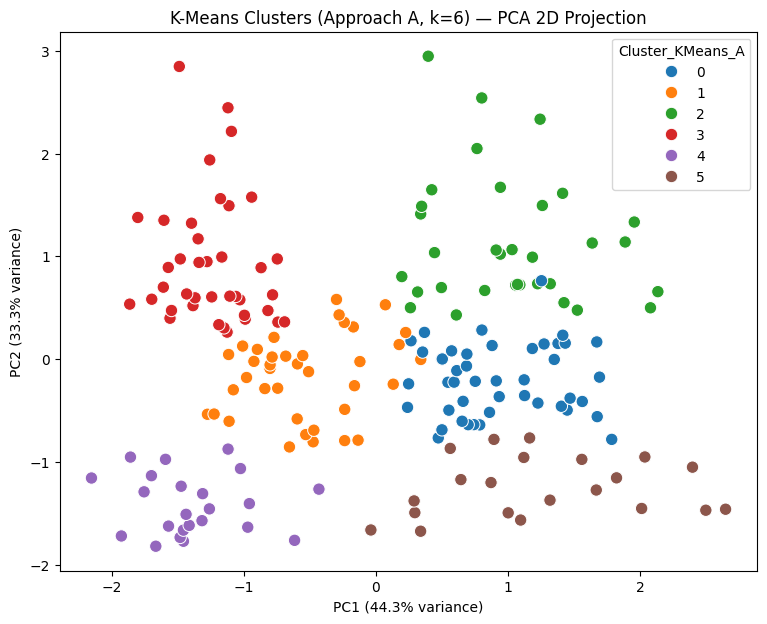

In [49]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster_KMeans_A',
    data=mallcus, palette='tab10', s=80
)
plt.title('K-Means Clusters (Approach A, k=6) — PCA 2D Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.show()

**Finding:** PCA reduces the 3 features to 2 principal components, capturing 77.6% of total variance (PC1: 44.3%, PC2: 33.3%), a reasonably good summary, though not exhaustive, of the original feature space.<br>
In this 2D projection, all 6 clusters are visibly distinguishable with only minor overlap at the boundaries (e.g., between clusters 0 and 1, and slight overlap between 0 and 5 in the lower-right region). <br>
This single 2D view confirms visually what the earlier separate 2D plots (Section 2.3) hinted at piecewise.<br>
The 6 clusters formed by K-Means on Age, Income, and Spending Score represent genuinely distinct, well-separated customer segments.

# Part 3: Interpretation and Insights

In [50]:
cluster_profile = mallcus.groupby('Cluster_KMeans_A')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = mallcus['Cluster_KMeans_A'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster_KMeans_A,,,,
0,56.3,54.3,49.1,45
1,26.8,57.1,48.1,39
2,41.9,88.9,17.0,33
3,32.7,86.5,82.1,39
4,25.0,25.3,77.6,23
5,45.5,26.3,19.4,21


### Cluster Profiles - Approach A (K-Means, k=6)

| Cluster | Age (avg) | Income (avg, k$) | Spending Score (avg) | Count | Segment Name |
|---|---|---|---|---|---|
| 0 | 56.3 | 54.3 | 49.1 | 45 | Established Moderate Spenders |
| 1 | 26.8 | 57.1 | 48.1 | 39 | Young Moderate Spenders |
| 2 | 41.9 | 88.9 | 17.0 | 33 | High-Income Low Spenders (Cautious) |
| 3 | 32.7 | 86.5 | 82.1 | 39 | High-Income High Spenders (Premium Target) |
| 4 | 25.0 | 25.3 | 77.6 | 23 | Young Low-Income High Spenders (Impulsive) |
| 5 | 45.5 | 26.3 | 19.4 | 21 | Older Low-Income Low Spenders (Budget-Conscious) |

**Finding:** Six clearly distinct customer segments emerge:
* **Clusters 0 & 1** (mid-range income, moderate spending) differ mainly by Age. Confirming our earlier observation that Age was the key separator between these two groups on the Income vs Spending plot.
* **Clusters 2 & 3** both have high income (85-90k) but their spending pattern differs. Cluster 3 spends more (82.1) while Cluster 2 is conservative (17.0), despite similar earning. This shows income alone doesn't determine spending, consistent with the near-zero correlation we found in Part 1 (0.0099).
* **Clusters 4 & 5** both have low income (25-26k) but again have different ways of spending. Cluster 4 is young and spends more (77.6) even though their income is low, while Cluster 5 is older but spends little (19.4). Age appears to correlate with spending caution here too, matching the -0.33 correlation we saw in Part 1.

### Practical Implications

* Cluster 3 (High-Income High Spenders) deserves the most attention out of all six groups. They're already spending more that others and have the income to keep it up.Therefore premium product lines, loyalty perks, and higher-margin promotions should be done to retain them.

* Cluster 2 (High-Income Low Spenders) is arguably the more interesting group. The income is there, it's just not being spent at the mall right now. Something like personalized outreach, VIP previews or tailored offers, could plausibly nudge some of that unused income into actual purchases.

* Cluster 4 (Young Low-Income High Spenders) wants to spend but doesn't have much room to do it. Installment plans, student discounts, or a loyalty setup that rewards frequency over transaction size would likely resonate more than anything premium-priced.

* Cluster 5 (Older Low-Income Low Spenders) along with Clusters 0/1 (Moderate Spenders) aren't big spenders and probably never will be, but value-oriented or essentials-based promotions could still get some traction with them.

### Limitations

* **Small sample size:** 200 customers isn't much to build firm conclusions on. Cluster boundaries and averages here may not hold up across the mall's broader customer base, and with some segments as small as 21–45 people, a handful of unusual customers could shift a cluster's profile more than you'd like.

* **No temporal or behavioral data:** This is a single snapshot, not a history. There's nothing here on purchase frequency, product categories, seasonal shifts, or how long someone's been a customer. Two people with the exact same Spending Score today could still turn out to have very different long-term value.

* **Spending Score itself isn't well defined.** It's a mall-assigned metric, but there's no documentation on how it's actually calculated, i.e whether it reflects how often someone buys, how much they spend, or some mix of both. That ambiguity makes it harder to act on the results with full confidence.

* **Adding Gender didn't help.** Approach B showed this clearly enough, silhouette scores dropped and the two clustering methods agreed less once Gender was included. That could mean Gender actually isn't a driver of spending here, or it could just be that the sample is too small to pick up a real effect either way.

* **K-Means isn't a neutral choice, it brings assumptions with it.** It tends to work best when clusters come out roughly round and evenly sized, which real customer behavior doesn't always cooperate with. The Ward-linkage Hierarchical clustering used alongside it shares a similar bias, so it's possible both methods are missing messier, less regular groupings that actually exist in the customer base.

### Recommendations

**For the business:**
* Cluster 3, the high-income high spenders, is the one to protect. They're already spending freely and clearly can afford to keep doing so, so retention and premium offers should go here first.

* Cluster 2 has the income to spend more but just isn't doing it. That gap is the opportunity. Some kind of targeted push, personalized offers or similar, could pull some of that unused income into actual purchases.

* Cluster 4 skews young and lower-income, but they're enthusiastic spenders within their means. Something like a loyalty program or installment option would probably keep them engaged without asking more of their budget than they have.

**For future analysis:**
* It would be worth collecting a few additional variables, such as purchase frequency, product category preferences, visit recency, and how long someone's been a mall member or loyalty participant. That would open the door to RFM-style segmentation (Recency, Frequency, Monetary) alongside the demographic clustering already done here.

* Tracking Spending Score over time would help answer a question this analysis can't; i.e, do customers actually move between clusters, or do they stay put? For example, do young high spenders eventually "graduate" into the high-income high-spender group as they age, or is that a separate population entirely? That would clarify whether these segments reflect stable customer types or just a life stage.

* Re-running the clustering periodically as more data comes in would also help, since a larger sample should produce segments that are more statistically robust and generalize better beyond this particular snapshot.